In [55]:
# ============================================================
# CELL 1: Imports, reproducibility, and output directories
# ============================================================

import os
import sys
import json
import math
import random
import shutil
import hashlib
import platform
import subprocess
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import datasets, transforms, models

from torch.utils.data import Dataset, DataLoader


# ------------------------------------------------------------
# Random seed
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Warn rather than crash if a CUDA operation has no deterministic version
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception:
    pass


# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ------------------------------------------------------------
# Output directory structure
# ------------------------------------------------------------

KAGGLE_INPUT_DIR = Path("/kaggle/input")
KAGGLE_WORKING_DIR = Path("/kaggle/working")

PROJECT_DIR = KAGGLE_WORKING_DIR / "ATDL_Teacher_ResNet34"

CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
PLOT_DIR = PROJECT_DIR / "plots"
LOG_DIR = PROJECT_DIR / "logs"
RESULT_DIR = PROJECT_DIR / "results"
CONFIG_DIR = PROJECT_DIR / "config"
ENV_DIR = PROJECT_DIR / "environment"

for folder in [
    PROJECT_DIR,
    CHECKPOINT_DIR,
    PLOT_DIR,
    LOG_DIR,
    RESULT_DIR,
    CONFIG_DIR,
    ENV_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Environment information
# ------------------------------------------------------------

environment_info = {
    "python_version": sys.version,
    "platform": platform.platform(),
    "pytorch_version": torch.__version__,
    "torchvision_version": torchvision.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_version": torch.version.cuda,
    "device": str(DEVICE),
    "gpu_name": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else "CPU"
    ),
    "seed": SEED,
}

with open(ENV_DIR / "environment.txt", "w") as f:
    for key, value in environment_info.items():
        f.write(f"{key}: {value}\n")


print("=" * 72)
print("ATDL Assignment 1 - Notebook 1")
print("FP32 ResNet34 Teacher")
print("=" * 72)

print(f"Device              : {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU                 : {torch.cuda.get_device_name(0)}")
    print(
        f"GPU memory          : "
        f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
    )

print(f"PyTorch             : {torch.__version__}")
print(f"Torchvision         : {torchvision.__version__}")
print(f"Random seed         : {SEED}")

print("\nProject directory:")
print(PROJECT_DIR)



ATDL Assignment 1 - Notebook 1
FP32 ResNet34 Teacher
Device              : cuda
GPU                 : Tesla T4
GPU memory          : 15.64 GB
PyTorch             : 2.10.0+cu128
Torchvision         : 0.25.0+cu128
Random seed         : 42

Project directory:
/kaggle/working/ATDL_Teacher_ResNet34


In [56]:
# ============================================================
# CELL 2: Teacher training configuration
# ============================================================

CONFIG = {
    # Experiment
    "experiment_name": "ResNet34_FP32_CIFAR10_Teacher",
    "seed": SEED,

    # Dataset
    "num_classes": 10,
    "train_size": 45000,
    "validation_size": 5000,

    # Optimization
    "batch_size": 128,
    "max_epochs": 200,
    "optimizer": "SGD",
    "learning_rate": 0.1,
    "momentum": 0.9,
    "nesterov": True,
    "weight_decay": 5e-4,
    
    # Loss
    "label_smoothing": 0.1,
    
    # LR scheduling
    "warmup_epochs": 5,
    "scheduler": "5-epoch linear warmup + ReduceLROnPlateau",
    "plateau_factor": 0.5,
    "plateau_patience": 8,
    "minimum_learning_rate": 1e-4,

    # Early stopping
    "early_stopping_patience": 20,

    # Data augmentation
    "random_crop": {
        "size": 32,
        "padding": 4,
    },
    "horizontal_flip_probability": 0.5,
    "cutout_size": 8,

    # CIFAR-10 channel statistics
    "normalization_mean": [0.4914, 0.4822, 0.4465],
    "normalization_std": [0.2470, 0.2435, 0.2616],

    # Model
    "architecture": "ResNet34",
    "precision": "FP32",
    "cifar_stem": True,

    # Selection rule
    "checkpoint_selection": "highest validation accuracy",
}


BATCH_SIZE = CONFIG["batch_size"]
MAX_EPOCHS = CONFIG["max_epochs"]

BASE_LR = CONFIG["learning_rate"]
MOMENTUM = CONFIG["momentum"]
WEIGHT_DECAY = CONFIG["weight_decay"]
NESTEROV = CONFIG["nesterov"]

LABEL_SMOOTHING = CONFIG["label_smoothing"]

WARMUP_EPOCHS = CONFIG["warmup_epochs"]

PLATEAU_FACTOR = CONFIG["plateau_factor"]
PLATEAU_PATIENCE = CONFIG["plateau_patience"]
MIN_LR = CONFIG["minimum_learning_rate"]

PATIENCE = CONFIG["early_stopping_patience"]

VAL_SIZE = CONFIG["validation_size"]
CUTOUT_SIZE = CONFIG["cutout_size"]

CIFAR_MEAN = tuple(CONFIG["normalization_mean"])
CIFAR_STD = tuple(CONFIG["normalization_std"])


# Kaggle usually works well with 2-4 workers
NUM_WORKERS = min(4, os.cpu_count() or 2)

CONFIG["num_workers"] = NUM_WORKERS


with open(CONFIG_DIR / "teacher_config.json", "w") as f:
    json.dump(CONFIG, f, indent=4)


print(json.dumps(CONFIG, indent=4))

print("\nConfiguration saved to:")
print(CONFIG_DIR / "teacher_config.json")

{
    "experiment_name": "ResNet34_FP32_CIFAR10_Teacher",
    "seed": 42,
    "num_classes": 10,
    "train_size": 45000,
    "validation_size": 5000,
    "batch_size": 128,
    "max_epochs": 200,
    "optimizer": "SGD",
    "learning_rate": 0.1,
    "momentum": 0.9,
    "nesterov": true,
    "weight_decay": 0.0005,
    "label_smoothing": 0.1,
    "warmup_epochs": 5,
    "scheduler": "5-epoch linear warmup + ReduceLROnPlateau",
    "plateau_factor": 0.5,
    "plateau_patience": 8,
    "minimum_learning_rate": 0.0001,
    "early_stopping_patience": 20,
    "random_crop": {
        "size": 32,
        "padding": 4
    },
    "horizontal_flip_probability": 0.5,
    "cutout_size": 8,
    "normalization_mean": [
        0.4914,
        0.4822,
        0.4465
    ],
    "normalization_std": [
        0.247,
        0.2435,
        0.2616
    ],
    "architecture": "ResNet34",
    "precision": "FP32",
    "cifar_stem": true,
    "checkpoint_selection": "highest validation accuracy",
    "num_

In [57]:
# ============================================================
# CELL 3: Locate existing CIFAR-10 Kaggle dataset
# ============================================================

print("Datasets available under /kaggle/input:\n")

for path in sorted(KAGGLE_INPUT_DIR.iterdir()):
    print(" -", path.name)


# ------------------------------------------------------------
# Locate CIFAR-10 Python batch directory
# ------------------------------------------------------------

required_cifar_files = {
    "data_batch_1",
    "data_batch_2",
    "data_batch_3",
    "data_batch_4",
    "data_batch_5",
    "test_batch",
    "batches.meta",
}

candidate_directories = []

for batch1_path in KAGGLE_INPUT_DIR.rglob("data_batch_1"):
    candidate_dir = batch1_path.parent

    existing_files = {p.name for p in candidate_dir.iterdir() if p.is_file()}

    if required_cifar_files.issubset(existing_files):
        candidate_directories.append(candidate_dir)


if len(candidate_directories) == 0:
    print("\nCould not automatically find the extracted CIFAR-10 batch directory.")
    print("Relevant CIFAR paths found:")

    for p in KAGGLE_INPUT_DIR.rglob("*"):
        if "cifar" in p.name.lower():
            print(p)

    raise FileNotFoundError(
        "CIFAR-10 Python batch files were not found. "
        "No download was attempted."
    )


print("\nValid CIFAR-10 directories found:")

for i, path in enumerate(candidate_directories):
    print(f"[{i}] {path}")


CIFAR_BATCH_DIR = candidate_directories[0]

# torchvision CIFAR10 expects:
# root/cifar-10-batches-py/data_batch_1
CIFAR_ROOT = CIFAR_BATCH_DIR.parent


print("\nSelected CIFAR batch directory:")
print(CIFAR_BATCH_DIR)

print("\nTorchvision root:")
print(CIFAR_ROOT)


# ------------------------------------------------------------
# Verify required files
# ------------------------------------------------------------

print("\nRequired CIFAR-10 files:")

for filename in sorted(required_cifar_files):
    filepath = CIFAR_BATCH_DIR / filename
    print(f"{filename:15s} -> {'FOUND' if filepath.exists() else 'MISSING'}")


assert all(
    (CIFAR_BATCH_DIR / filename).exists()
    for filename in required_cifar_files
), "Not all required CIFAR-10 batch files exist."


print("\nCIFAR-10 dataset successfully located.")
print("NO DATASET DOWNLOAD WAS PERFORMED.")

Datasets available under /kaggle/input:

 - datasets

Valid CIFAR-10 directories found:
[0] /kaggle/input/datasets/kshitianilkumar/cifar-10/cifar/data/cifar-10-batches-py
[1] /kaggle/input/datasets/kshitianilkumar/cifar-10/cifar/data/cifar-10-python/cifar-10-batches-py

Selected CIFAR batch directory:
/kaggle/input/datasets/kshitianilkumar/cifar-10/cifar/data/cifar-10-batches-py

Torchvision root:
/kaggle/input/datasets/kshitianilkumar/cifar-10/cifar/data

Required CIFAR-10 files:
batches.meta    -> FOUND
data_batch_1    -> FOUND
data_batch_2    -> FOUND
data_batch_3    -> FOUND
data_batch_4    -> FOUND
data_batch_5    -> FOUND
test_batch      -> FOUND

CIFAR-10 dataset successfully located.
NO DATASET DOWNLOAD WAS PERFORMED.


In [58]:
# ============================================================
# CELL 4: Cutout and CIFAR-10 transformations
# ============================================================

class Cutout:
    """
    Randomly masks one square region of an image tensor.

    The input is expected to be a tensor with shape:
        [C, H, W]

    Cutout is applied before normalization.
    """

    def __init__(self, size=8):
        self.size = size

    def __call__(self, tensor):

        if not torch.is_tensor(tensor):
            raise TypeError("Cutout expects a torch Tensor.")

        _, height, width = tensor.shape

        center_y = torch.randint(0, height, (1,)).item()
        center_x = torch.randint(0, width, (1,)).item()

        half = self.size // 2

        y1 = max(0, center_y - half)
        y2 = min(height, center_y + half)

        x1 = max(0, center_x - half)
        x2 = min(width, center_x + half)

        tensor = tensor.clone()

        tensor[:, y1:y2, x1:x2] = 0.0

        return tensor

    def __repr__(self):
        return f"{self.__class__.__name__}(size={self.size})"


# ------------------------------------------------------------
# Training transform
# ------------------------------------------------------------

train_transform = transforms.Compose([
    transforms.RandomCrop(
        32,
        padding=4
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.ToTensor(),

    Cutout(
        size=CUTOUT_SIZE
    ),

    transforms.Normalize(
        CIFAR_MEAN,
        CIFAR_STD
    ),
])


# ------------------------------------------------------------
# Validation and test transforms
# No random augmentation
# ------------------------------------------------------------

eval_transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        CIFAR_MEAN,
        CIFAR_STD
    ),
])


print("Training transform:")
print(train_transform)

print("\nValidation/Test transform:")
print(eval_transform)

print("\nCIFAR-10 mean:", CIFAR_MEAN)
print("CIFAR-10 std :", CIFAR_STD)

Training transform:
Compose(
    RandomCrop(size=(32, 32), padding=4)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Cutout(size=8)
    Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))
)

Validation/Test transform:
Compose(
    ToTensor()
    Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))
)

CIFAR-10 mean: (0.4914, 0.4822, 0.4465)
CIFAR-10 std : (0.247, 0.2435, 0.2616)


In [59]:
# ============================================================
# CELL 5: Load existing CIFAR-10 training data
# ============================================================

base_train_dataset = datasets.CIFAR10(
    root=str(CIFAR_ROOT),
    train=True,
    download=False,
    transform=None
)


print("Original CIFAR-10 training samples:")
print(len(base_train_dataset))

print("\nClasses:")
print(base_train_dataset.classes)

print("\nClass-to-index mapping:")
print(base_train_dataset.class_to_idx)


assert len(base_train_dataset) == 50000
assert len(base_train_dataset.classes) == 10


print("\nExisting CIFAR-10 dataset loaded successfully.")
print("download=False was used.")

Original CIFAR-10 training samples:
50000

Classes:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Class-to-index mapping:
{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}

Existing CIFAR-10 dataset loaded successfully.
download=False was used.


In [60]:
# ============================================================
# CELL 6: Deterministic stratified train/validation split
# ============================================================

targets = np.array(base_train_dataset.targets)

rng = np.random.default_rng(SEED)

train_indices = []
val_indices = []

NUM_CLASSES = 10
VAL_PER_CLASS = VAL_SIZE // NUM_CLASSES


for class_id in range(NUM_CLASSES):

    class_indices = np.where(targets == class_id)[0]

    rng.shuffle(class_indices)

    class_val_indices = class_indices[:VAL_PER_CLASS]
    class_train_indices = class_indices[VAL_PER_CLASS:]

    val_indices.extend(class_val_indices.tolist())
    train_indices.extend(class_train_indices.tolist())


# Shuffle final index order deterministically
rng.shuffle(train_indices)
rng.shuffle(val_indices)

train_indices = np.array(train_indices)
val_indices = np.array(val_indices)


print("Training samples   :", len(train_indices))
print("Validation samples :", len(val_indices))

assert len(train_indices) == 45000
assert len(val_indices) == 5000

assert len(set(train_indices).intersection(set(val_indices))) == 0


# ------------------------------------------------------------
# Verify class distributions
# ------------------------------------------------------------

train_distribution = Counter(targets[train_indices])
val_distribution = Counter(targets[val_indices])


print("\nTraining class distribution:")

for class_id in range(NUM_CLASSES):
    print(
        f"{base_train_dataset.classes[class_id]:10s}: "
        f"{train_distribution[class_id]}"
    )


print("\nValidation class distribution:")

for class_id in range(NUM_CLASSES):
    print(
        f"{base_train_dataset.classes[class_id]:10s}: "
        f"{val_distribution[class_id]}"
    )


# ------------------------------------------------------------
# Save split indices
# ------------------------------------------------------------

np.savez(
    CONFIG_DIR / "cifar10_split_indices.npz",
    train_indices=train_indices,
    val_indices=val_indices,
    seed=SEED
)


dataset_info = {
    "dataset": "CIFAR-10",
    "source": str(CIFAR_BATCH_DIR),
    "original_training_images": 50000,
    "training_images": len(train_indices),
    "validation_images": len(val_indices),
    "official_test_images": 10000,
    "validation_examples_per_class": VAL_PER_CLASS,
    "split_seed": SEED,
    "classes": base_train_dataset.classes,
    "train_distribution": {
        base_train_dataset.classes[i]: int(train_distribution[i])
        for i in range(NUM_CLASSES)
    },
    "validation_distribution": {
        base_train_dataset.classes[i]: int(val_distribution[i])
        for i in range(NUM_CLASSES)
    }
}


with open(RESULT_DIR / "dataset_info.json", "w") as f:
    json.dump(dataset_info, f, indent=4)


print("\nSplit indices saved.")

Training samples   : 45000
Validation samples : 5000

Training class distribution:
airplane  : 4500
automobile: 4500
bird      : 4500
cat       : 4500
deer      : 4500
dog       : 4500
frog      : 4500
horse     : 4500
ship      : 4500
truck     : 4500

Validation class distribution:
airplane  : 500
automobile: 500
bird      : 500
cat       : 500
deer      : 500
dog       : 500
frog      : 500
horse     : 500
ship      : 500
truck     : 500

Split indices saved.


In [61]:
# ============================================================
# CELL 7: Dataset wrapper with separate transformations
# ============================================================

class CIFARSubset(Dataset):

    def __init__(self, base_dataset, indices, transform=None):

        self.base_dataset = base_dataset
        self.indices = np.asarray(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):

        original_idx = self.indices[idx]

        image = self.base_dataset.data[original_idx]
        label = self.base_dataset.targets[original_idx]

        image = Image.fromarray(image)

        if self.transform is not None:
            image = self.transform(image)

        return image, label


train_dataset = CIFARSubset(
    base_train_dataset,
    train_indices,
    transform=train_transform
)


val_dataset = CIFARSubset(
    base_train_dataset,
    val_indices,
    transform=eval_transform
)


print("Training dataset   :", len(train_dataset))
print("Validation dataset :", len(val_dataset))


sample_image, sample_label = train_dataset[0]

print("\nSample tensor shape:", sample_image.shape)
print("Sample label       :", sample_label)
print("Class              :", base_train_dataset.classes[sample_label])


assert sample_image.shape == (3, 32, 32)

Training dataset   : 45000
Validation dataset : 5000

Sample tensor shape: torch.Size([3, 32, 32])
Sample label       : 8
Class              : ship


In [62]:
# ============================================================
# CELL 8: DataLoaders
# ============================================================

def seed_worker(worker_id):

    worker_seed = torch.initial_seed() % (2**32)

    np.random.seed(worker_seed)
    random.seed(worker_seed)


loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0),
    worker_init_fn=seed_worker,
    generator=loader_generator
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0),
    worker_init_fn=seed_worker
)


print("Training batches   :", len(train_loader))
print("Validation batches :", len(val_loader))


images, labels = next(iter(train_loader))

print("\nBatch image shape:", images.shape)
print("Batch label shape:", labels.shape)

assert images.shape[1:] == (3, 32, 32)

Training batches   : 352
Validation batches : 40

Batch image shape: torch.Size([128, 3, 32, 32])
Batch label shape: torch.Size([128])


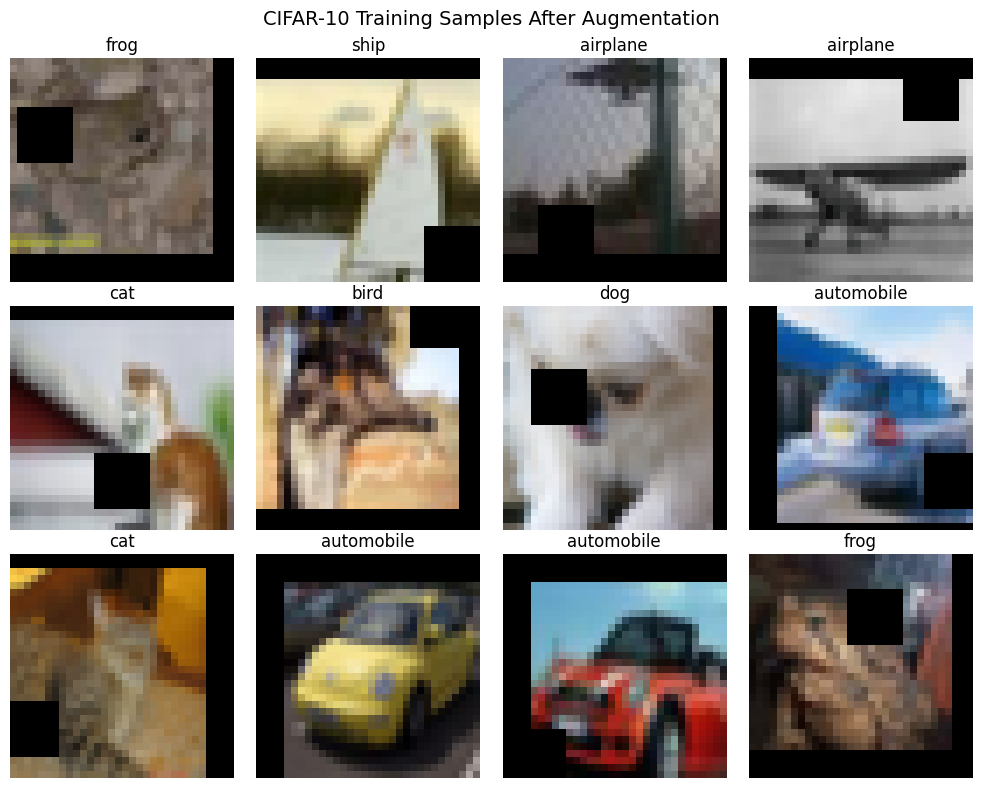

Saved:
/kaggle/working/ATDL_Teacher_ResNet34/plots/training_augmentation_examples.png


In [63]:
# ============================================================
# CELL 9: Visual sanity check of training augmentation
# ============================================================

def denormalize(image_tensor):

    mean = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR_STD).view(3, 1, 1)

    image_tensor = image_tensor.cpu() * std + mean

    return torch.clamp(image_tensor, 0, 1)


images, labels = next(iter(train_loader))

fig, axes = plt.subplots(3, 4, figsize=(10, 8))

for i, ax in enumerate(axes.flat):

    image = denormalize(images[i])

    image = image.permute(1, 2, 0).numpy()

    ax.imshow(image)

    ax.set_title(
        base_train_dataset.classes[labels[i].item()]
    )

    ax.axis("off")


plt.suptitle(
    "CIFAR-10 Training Samples After Augmentation",
    fontsize=14
)

plt.tight_layout()

augmentation_plot_path = (
    PLOT_DIR / "training_augmentation_examples.png"
)

plt.savefig(
    augmentation_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(augmentation_plot_path)

In [64]:
# ============================================================
# CELL 10: Build CIFAR-10 adapted ResNet34
# ============================================================

def build_cifar_resnet34(num_classes=10):

    # weights=None means training from scratch
    model = models.resnet34(
        weights=None,
        num_classes=num_classes
    )

    # --------------------------------------------------------
    # Replace ImageNet stem
    # --------------------------------------------------------

    model.conv1 = nn.Conv2d(
        in_channels=3,
        out_channels=64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False
    )

    # Explicit ResNet-style initialization
    nn.init.kaiming_normal_(
        model.conv1.weight,
        mode="fan_out",
        nonlinearity="relu"
    )

    # No initial spatial downsampling
    model.maxpool = nn.Identity()

    return model


model = build_cifar_resnet34(
    num_classes=10
)

model = model.to(DEVICE)


# ------------------------------------------------------------
# Parameter count
# ------------------------------------------------------------

total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print(model)

print("\n" + "=" * 72)

print(f"Total parameters     : {total_parameters:,}")
print(f"Trainable parameters : {trainable_parameters:,}")


# ------------------------------------------------------------
# Forward-pass sanity check
# ------------------------------------------------------------

dummy = torch.randn(
    4,
    3,
    32,
    32,
    device=DEVICE
)


model.eval()

with torch.no_grad():
    dummy_output = model(dummy)


print("\nInput shape :", dummy.shape)
print("Output shape:", dummy_output.shape)


assert dummy_output.shape == (4, 10)


model.train()


# ------------------------------------------------------------
# Save model architecture
# ------------------------------------------------------------

with open(RESULT_DIR / "model_info.txt", "w") as f:

    f.write("ATDL Assignment 1 - Teacher Model\n")
    f.write("=" * 60 + "\n\n")

    f.write("Architecture: ResNet34\n")
    f.write("Precision: FP32\n")
    f.write("Dataset: CIFAR-10\n\n")

    f.write("CIFAR-10 modifications:\n")
    f.write("- conv1: 3x3, stride=1, padding=1\n")
    f.write("- initial maxpool removed\n")
    f.write("- output classes: 10\n\n")

    f.write(f"Total parameters: {total_parameters:,}\n")
    f.write(f"Trainable parameters: {trainable_parameters:,}\n\n")

    f.write(str(model))


print("\nModel sanity check passed.")

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

In [65]:
# ============================================================
# CELL 11: Loss, optimizer, warmup + ReduceLROnPlateau
# Full FP32 teacher training
# ============================================================

# ------------------------------------------------------------
# Cross-entropy with label smoothing
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss(
    label_smoothing=LABEL_SMOOTHING
)


# ------------------------------------------------------------
# SGD optimizer
# ------------------------------------------------------------

optimizer = optim.SGD(
    model.parameters(),
    lr=BASE_LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
    nesterov=NESTEROV
)


# ------------------------------------------------------------
# Adaptive LR reduction after warmup
#
# If validation loss stops improving for 8 epochs:
#     LR = LR * 0.5
#
# LR will not fall below 1e-4.
# ------------------------------------------------------------

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=PLATEAU_FACTOR,
    patience=PLATEAU_PATIENCE,
    min_lr=MIN_LR
)


print("Loss                : CrossEntropyLoss")
print("Label smoothing     :", LABEL_SMOOTHING)

print("\nOptimizer           : SGD")
print("Base learning rate  :", BASE_LR)
print("Momentum            :", MOMENTUM)
print("Nesterov            :", NESTEROV)
print("Weight decay        :", WEIGHT_DECAY)

print("\nWarmup epochs       :", WARMUP_EPOCHS)

print("\nScheduler           : ReduceLROnPlateau")
print("Plateau factor      :", PLATEAU_FACTOR)
print("Plateau patience    :", PLATEAU_PATIENCE)
print("Minimum LR          :", MIN_LR)

print("\nEarly-stop patience :", PATIENCE)

print("\nTraining precision  : FP32")

Loss                : CrossEntropyLoss
Label smoothing     : 0.1

Optimizer           : SGD
Base learning rate  : 0.1
Momentum            : 0.9
Nesterov            : True
Weight decay        : 0.0005

Warmup epochs       : 5

Scheduler           : ReduceLROnPlateau
Plateau factor      : 0.5
Plateau patience    : 8
Minimum LR          : 0.0001

Early-stop patience : 20

Training precision  : FP32


In [66]:
# ============================================================
# CELL 12: FP32 training and validation functions
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0


    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        # Clear gradients from previous iteration
        optimizer.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # FP32 forward pass
        # ----------------------------------------------------

        logits = model(images)

        loss = criterion(
            logits,
            labels
        )


        # ----------------------------------------------------
        # FP32 backward pass
        # ----------------------------------------------------

        loss.backward()

        optimizer.step()


        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        batch_size = labels.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        predictions = logits.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += batch_size


    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        100.0 * correct / total
    )


    return epoch_loss, epoch_accuracy



@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0


    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        logits = model(images)

        loss = criterion(
            logits,
            labels
        )


        batch_size = labels.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        predictions = logits.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += batch_size


    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        100.0 * correct / total
    )


    return epoch_loss, epoch_accuracy


print("FP32 training/evaluation functions ready.")

FP32 training/evaluation functions ready.


In [67]:
# ============================================================
# CELL 13: Train ResNet34 teacher
# ============================================================

BEST_CHECKPOINT_PATH = (
    CHECKPOINT_DIR / "teacher.pth"
)


history = {
    "epoch": [],
    "learning_rate": [],
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
}


best_val_accuracy = -float("inf")
best_val_loss = float("inf")

best_epoch = 0

epochs_without_improvement = 0


print("=" * 100)
print("STARTING RESNET34 TEACHER TRAINING")
print("=" * 100)

print(
    f"{'Epoch':>6} "
    f"{'LR':>11} "
    f"{'Train Loss':>12} "
    f"{'Train Acc':>11} "
    f"{'Val Loss':>12} "
    f"{'Val Acc':>11} "
    f"{'Patience':>10}"
)

print("-" * 100)


for epoch in range(1, MAX_EPOCHS + 1):

    # ========================================
    # WARMUP
    # ========================================

    if epoch <= WARMUP_EPOCHS:
    
        warmup_lr = BASE_LR * (
            epoch / WARMUP_EPOCHS
        )
    
        for param_group in optimizer.param_groups:
            param_group["lr"] = warmup_lr
    
        print(
            f"[Warmup] Epoch {epoch}/{WARMUP_EPOCHS} "
            f"-> Learning Rate = {warmup_lr:.6f}"
        )
    
    
    current_lr = optimizer.param_groups[0]["lr"]

    # ========================================
    # TRAIN
    # ========================================

    train_loss, train_accuracy = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE
    )


    # ========================================
    # VALIDATION
    # ========================================

    val_loss, val_accuracy = evaluate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=DEVICE
    )


    # ========================================
    # HISTORY
    # ========================================

    history["epoch"].append(epoch)
    history["learning_rate"].append(float(current_lr))
    history["train_loss"].append(float(train_loss))
    history["train_accuracy"].append(float(train_accuracy))
    history["val_loss"].append(float(val_loss))
    history["val_accuracy"].append(float(val_accuracy))


    # ========================================
    # BEST CHECKPOINT
    # ========================================

    improved = False

    if val_accuracy > best_val_accuracy + 1e-8:

        improved = True

    elif (
        abs(val_accuracy - best_val_accuracy) <= 1e-8
        and val_loss < best_val_loss
    ):

        improved = True


    if improved:

        best_val_accuracy = val_accuracy
        best_val_loss = val_loss
        best_epoch = epoch

        epochs_without_improvement = 0

        cpu_state_dict = {
            key: value.detach().cpu()
            for key, value in model.state_dict().items()
        }

        checkpoint = {
            "architecture": "ResNet34",
            "dataset": "CIFAR-10",
            "precision": "FP32",

            "epoch": epoch,

            "model_state_dict": cpu_state_dict,

            "best_val_accuracy": float(best_val_accuracy),
            "best_val_loss": float(best_val_loss),

            "total_parameters": int(total_parameters),

            "config": CONFIG,

            "classes": base_train_dataset.classes,

            "cifar_stem": {
                "conv1_kernel": 3,
                "conv1_stride": 1,
                "conv1_padding": 1,
                "maxpool": False,
            }
        }

        torch.save(
            checkpoint,
            BEST_CHECKPOINT_PATH
        )

    else:

        epochs_without_improvement += 1


    # ========================================
    # SAVE HISTORY
    # ========================================

    history_df = pd.DataFrame(history)

    history_df.to_csv(
        LOG_DIR / "training_history.csv",
        index=False
    )

    with open(
        LOG_DIR / "training_history.json",
        "w"
    ) as f:

        json.dump(
            history,
            f,
            indent=4
        )


    # ========================================
    # PRINT
    # ========================================

    marker = " *BEST*" if improved else ""

    print(
        f"{epoch:6d} "
        f"{current_lr:11.6f} "
        f"{train_loss:12.4f} "
        f"{train_accuracy:10.2f}% "
        f"{val_loss:12.4f} "
        f"{val_accuracy:10.2f}% "
        f"{epochs_without_improvement:10d}"
        f"{marker}"
    )

    # ========================================
    # REDUCE LR ON PLATEAU
    # ========================================

    if epoch > WARMUP_EPOCHS:

        scheduler.step(val_loss)


    # ========================================
    # EARLY STOPPING
    # ========================================

    if epochs_without_improvement >= PATIENCE:

        print("\n" + "=" * 100)

        print(
            f"EARLY STOPPING: "
            f"No validation accuracy improvement "
            f"for {PATIENCE} epochs."
        )

        print(
            f"Best epoch: {best_epoch}"
        )

        print(
            f"Best validation accuracy: "
            f"{best_val_accuracy:.2f}%"
        )

        print("=" * 100)

        break


epochs_completed = len(
    history["epoch"]
)


print("\nTraining complete.")

print(
    f"Epochs completed        : "
    f"{epochs_completed}"
)

print(
    f"Best epoch              : "
    f"{best_epoch}"
)

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy:.2f}%"
)

print(
    f"Best validation loss    : "
    f"{best_val_loss:.4f}"
)

print("\nBest checkpoint:")
print(BEST_CHECKPOINT_PATH)

STARTING RESNET34 TEACHER TRAINING
 Epoch          LR   Train Loss   Train Acc     Val Loss     Val Acc   Patience
----------------------------------------------------------------------------------------------------
[Warmup] Epoch 1/5 -> Learning Rate = 0.020000
     1    0.020000       1.8048      39.29%       1.5820      51.56%          0 *BEST*
[Warmup] Epoch 2/5 -> Learning Rate = 0.040000
     2    0.040000       1.4548      56.63%       1.3397      62.44%          0 *BEST*
[Warmup] Epoch 3/5 -> Learning Rate = 0.060000
     3    0.060000       1.2358      67.36%       1.2076      69.18%          0 *BEST*
[Warmup] Epoch 4/5 -> Learning Rate = 0.080000
     4    0.080000       1.1333      72.35%       1.1493      72.48%          0 *BEST*
[Warmup] Epoch 5/5 -> Learning Rate = 0.100000
     5    0.100000       1.0665      75.04%       1.0840      74.38%          0 *BEST*
     6    0.100000       1.0077      78.08%       1.1176      72.96%          1
     7    0.100000       0.9637   

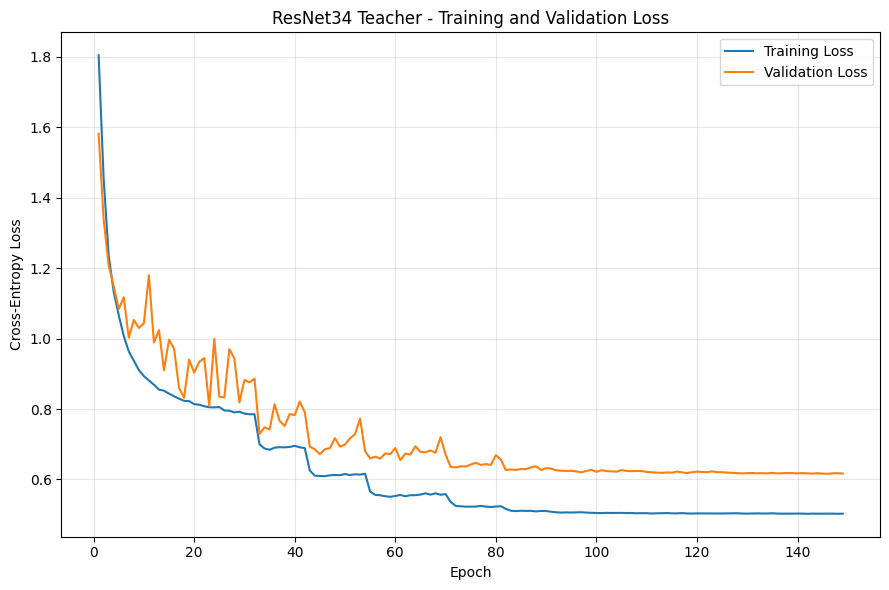

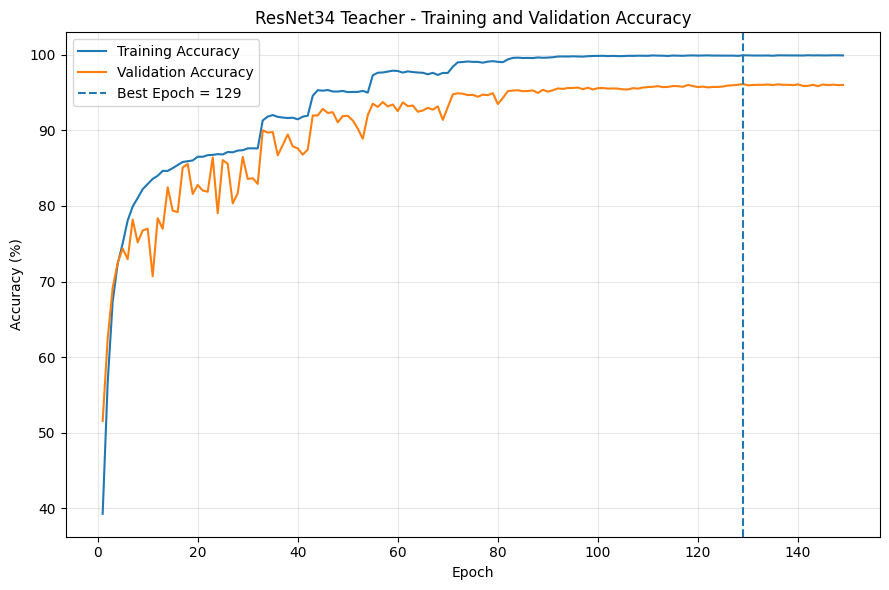

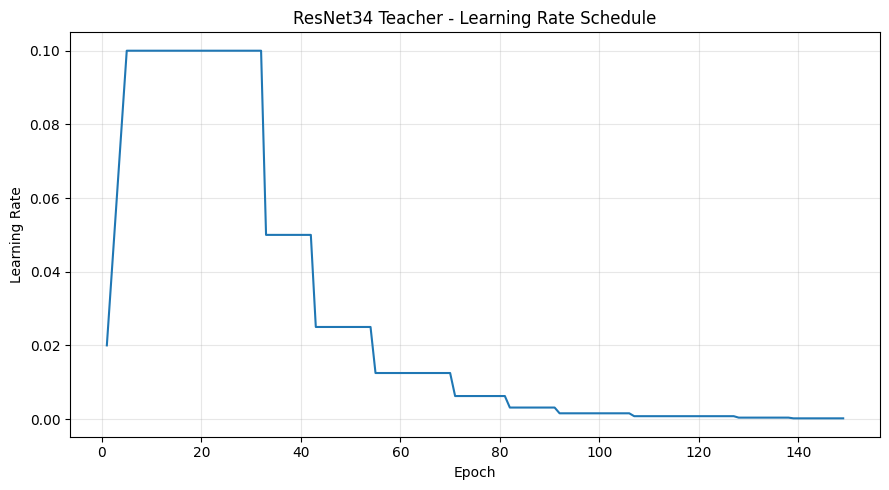

Plots saved to:
/kaggle/working/ATDL_Teacher_ResNet34/plots


In [76]:
# ============================================================
# CELL 14: Plot teacher training curves
# ============================================================

history_df = pd.read_csv(
    LOG_DIR / "training_history.csv"
)


# ------------------------------------------------------------
# Loss curve
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")

plt.title(
    "ResNet34 Teacher - Training and Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

loss_plot_path = (
    PLOT_DIR / "teacher_loss_curves.png"
)

plt.savefig(
    loss_plot_path,
    dpi=250,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Accuracy curve
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "ResNet34 Teacher - Training and Validation Accuracy"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

accuracy_plot_path = (
    PLOT_DIR / "teacher_accuracy_curves.png"
)

plt.savefig(
    accuracy_plot_path,
    dpi=250,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Learning-rate curve
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["learning_rate"]
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")

plt.title(
    "ResNet34 Teacher - Learning Rate Schedule"
)

plt.grid(alpha=0.3)

plt.tight_layout()

lr_plot_path = (
    PLOT_DIR / "teacher_learning_rate.png"
)

plt.savefig(
    lr_plot_path,
    dpi=250,
    bbox_inches="tight"
)

plt.show()


print("Plots saved to:")
print(PLOT_DIR)

In [77]:
# ============================================================
# CELL 15: Reload best teacher checkpoint
# ============================================================

assert BEST_CHECKPOINT_PATH.exists(), (
    "teacher.pth was not found."
)


checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False
)


best_teacher = build_cifar_resnet34(
    num_classes=10
)

best_teacher.load_state_dict(
    checkpoint["model_state_dict"]
)

best_teacher = best_teacher.to(DEVICE)

best_teacher.eval()


print("Best teacher checkpoint loaded.")

print(
    "Checkpoint epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation accuracy:",
    f"{checkpoint['best_val_accuracy']:.2f}%"
)

print(
    "Best validation loss:",
    f"{checkpoint['best_val_loss']:.4f}"
)


# Verify restored validation performance
restored_val_loss, restored_val_accuracy = evaluate(
    best_teacher,
    val_loader,
    criterion,
    DEVICE
)


print("\nRestored checkpoint validation:")

print(
    f"Validation loss     : "
    f"{restored_val_loss:.4f}"
)

print(
    f"Validation accuracy : "
    f"{restored_val_accuracy:.2f}%"
)

Best teacher checkpoint loaded.
Checkpoint epoch: 129
Best validation accuracy: 96.12%
Best validation loss: 0.6170

Restored checkpoint validation:
Validation loss     : 0.6170
Validation accuracy : 96.12%


In [70]:
# ============================================================
# CELL 16: Create clean training set and official test set
# ONLY AFTER MODEL SELECTION
# ============================================================

# ------------------------------------------------------------
# Full clean training dataset
# Used only to measure final clean training accuracy and
# generalization gap.
# ------------------------------------------------------------

clean_train_dataset = datasets.CIFAR10(
    root=str(CIFAR_ROOT),
    train=True,
    download=False,
    transform=eval_transform
)


clean_train_loader = DataLoader(
    clean_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0)
)


# ------------------------------------------------------------
# Official CIFAR-10 test dataset
#
# IMPORTANT:
# This has not been used for checkpoint/model selection.
# ------------------------------------------------------------

test_dataset = datasets.CIFAR10(
    root=str(CIFAR_ROOT),
    train=False,
    download=False,
    transform=eval_transform
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0)
)


print("Clean training samples :", len(clean_train_dataset))
print("Official test samples  :", len(test_dataset))

assert len(clean_train_dataset) == 50000
assert len(test_dataset) == 10000

print("\nOfficial test set is ready for FINAL evaluation.")

Clean training samples : 50000
Official test samples  : 10000

Official test set is ready for FINAL evaluation.


In [71]:
# ============================================================
# CELL 17: FINAL teacher evaluation
# ============================================================

print("=" * 72)
print("FINAL RESNET34 TEACHER EVALUATION")
print("=" * 72)


# ------------------------------------------------------------
# Clean training performance
# ------------------------------------------------------------

clean_train_loss, clean_train_accuracy = evaluate(
    best_teacher,
    clean_train_loader,
    criterion,
    DEVICE
)


# ------------------------------------------------------------
# Official test performance
# ------------------------------------------------------------

test_loss, test_accuracy = evaluate(
    best_teacher,
    test_loader,
    criterion,
    DEVICE
)


generalization_gap = (
    clean_train_accuracy -
    test_accuracy
)


print(
    f"Clean training loss     : "
    f"{clean_train_loss:.4f}"
)

print(
    f"Clean training accuracy : "
    f"{clean_train_accuracy:.2f}%"
)


print(
    f"\nBest validation loss    : "
    f"{restored_val_loss:.4f}"
)

print(
    f"Best validation accuracy: "
    f"{restored_val_accuracy:.2f}%"
)


print(
    f"\nOfficial test loss      : "
    f"{test_loss:.4f}"
)

print(
    f"Official test accuracy  : "
    f"{test_accuracy:.2f}%"
)


print(
    f"\nTrain-test accuracy gap : "
    f"{generalization_gap:.2f} percentage points"
)


FINAL RESNET34 TEACHER EVALUATION
Clean training loss     : 0.5121
Clean training accuracy : 99.61%

Best validation loss    : 0.6170
Best validation accuracy: 96.12%

Official test loss      : 0.6264
Official test accuracy  : 95.40%

Train-test accuracy gap : 4.21 percentage points


In [72]:
# ============================================================
# CELL 18: Per-class test accuracy
# ============================================================

class_correct = np.zeros(10, dtype=np.int64)
class_total = np.zeros(10, dtype=np.int64)


best_teacher.eval()


with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )


        outputs = best_teacher(images)

        predictions = outputs.argmax(
            dim=1
        )


        for class_id in range(10):

            class_mask = (
                labels == class_id
            )

            class_total[class_id] += (
                class_mask.sum().item()
            )

            class_correct[class_id] += (
                (
                    predictions[class_mask]
                    ==
                    labels[class_mask]
                )
                .sum()
                .item()
            )


per_class_results = []


print("Per-class test accuracy:\n")


for class_id, class_name in enumerate(
    test_dataset.classes
):

    accuracy = (
        100.0
        * class_correct[class_id]
        / class_total[class_id]
    )


    per_class_results.append({
        "class": class_name,
        "correct": int(
            class_correct[class_id]
        ),
        "total": int(
            class_total[class_id]
        ),
        "accuracy": float(
            accuracy
        )
    })


    print(
        f"{class_name:10s}: "
        f"{accuracy:6.2f}%"
    )


pd.DataFrame(
    per_class_results
).to_csv(
    RESULT_DIR / "teacher_per_class_accuracy.csv",
    index=False
)

Per-class test accuracy:

airplane  :  96.10%
automobile:  98.10%
bird      :  94.30%
cat       :  90.00%
deer      :  95.90%
dog       :  92.10%
frog      :  97.00%
horse     :  96.70%
ship      :  96.80%
truck     :  97.00%


In [73]:
# ============================================================
# CELL 19: Display generated artifact tree
# ============================================================

print(
    "Generated Notebook 1 artifacts:\n"
)


for root, dirs, files in os.walk(
    PROJECT_DIR
):

    level = (
        str(root)
        .replace(
            str(PROJECT_DIR),
            ""
        )
        .count(os.sep)
    )

    indent = "    " * level

    print(
        f"{indent}"
        f"{Path(root).name}/"
    )


    subindent = (
        "    " * (level + 1)
    )


    for file in sorted(files):

        file_path = (
            Path(root) / file
        )

        size_mb = (
            file_path.stat().st_size
            / (1024 ** 2)
        )

        print(
            f"{subindent}"
            f"{file} "
            f"({size_mb:.2f} MiB)"
        )

Generated Notebook 1 artifacts:

ATDL_Teacher_ResNet34/
    environment/
        environment.txt (0.00 MiB)
    config/
        cifar10_split_indices.npz (0.38 MiB)
        teacher_config.json (0.00 MiB)
    checkpoints/
        teacher.pth (81.31 MiB)
    logs/
        training_history.csv (0.01 MiB)
        training_history.json (0.02 MiB)
    results/
        dataset_info.json (0.00 MiB)
        model_info.txt (0.01 MiB)
        teacher_per_class_accuracy.csv (0.00 MiB)
    plots/
        teacher_accuracy_curves.png (0.15 MiB)
        teacher_learning_rate.png (0.07 MiB)
        teacher_loss_curves.png (0.14 MiB)
        training_augmentation_examples.png (0.09 MiB)


In [74]:
# ============================================================
# CELL 20: Save final teacher metrics
# ============================================================

checkpoint_size_bytes = os.path.getsize(
    BEST_CHECKPOINT_PATH
)

checkpoint_size_mb = (
    checkpoint_size_bytes /
    (1024 ** 2)
)


final_metrics = {

    "model": "ResNet34 FP32 Teacher",

    "architecture": "ResNet34",""

    "precision": "FP32",

    "best_epoch":
        int(best_epoch),

    "epochs_completed":
        int(epochs_completed),

    "best_validation_loss":
        float(restored_val_loss),

    "best_validation_accuracy":
        float(restored_val_accuracy),

    "clean_training_loss":
        float(clean_train_loss),

    "clean_training_accuracy":
        float(clean_train_accuracy),

    "official_test_loss":
        float(test_loss),

    "official_test_accuracy":
        float(test_accuracy),

    "train_test_accuracy_gap":
        float(generalization_gap),

    "total_parameters":
        int(total_parameters),

    "trainable_parameters":
        int(trainable_parameters),

    "checkpoint_path":
        str(BEST_CHECKPOINT_PATH),

    "checkpoint_size_bytes":
        int(checkpoint_size_bytes),

    "checkpoint_size_mb":
        float(checkpoint_size_mb),

    "random_seed":
        SEED,

    "test_set_used_for_model_selection":
        False
}


with open(
    RESULT_DIR / "teacher_final_metrics.json",
    "w"
) as f:

    json.dump(
        final_metrics,
        f,
        indent=4
    )


print(
    json.dumps(
        final_metrics,
        indent=4
    )
)


print("\nMetrics saved to:")

print(
    RESULT_DIR /
    "teacher_final_metrics.json"
)

{
    "model": "ResNet34 FP32 Teacher",
    "architecture": "ResNet34",
    "precision": "FP32",
    "best_epoch": 129,
    "epochs_completed": 149,
    "best_validation_loss": 0.6170260993957519,
    "best_validation_accuracy": 96.12,
    "clean_training_loss": 0.5121454695701599,
    "clean_training_accuracy": 99.612,
    "official_test_loss": 0.626364395904541,
    "official_test_accuracy": 95.4,
    "train_test_accuracy_gap": 4.211999999999989,
    "total_parameters": 21282122,
    "trainable_parameters": 21282122,
    "checkpoint_path": "/kaggle/working/ATDL_Teacher_ResNet34/checkpoints/teacher.pth",
    "checkpoint_size_bytes": 85262667,
    "checkpoint_size_mb": 81.31281566619873,
    "random_seed": 42,
    "test_set_used_for_model_selection": false
}

Metrics saved to:
/kaggle/working/ATDL_Teacher_ResNet34/results/teacher_final_metrics.json


In [78]:
# ============================================================
# CELL 21: Create final ZIP archive
# ============================================================

ZIP_BASE = (
    KAGGLE_WORKING_DIR /
    "ATDL_Teacher_ResNet34"
)


zip_path = shutil.make_archive(
    base_name=str(ZIP_BASE),
    format="zip",
    root_dir=str(KAGGLE_WORKING_DIR),
    base_dir=PROJECT_DIR.name
)


zip_size_mb = (
    os.path.getsize(zip_path)
    / (1024 ** 2)
)


print("=" * 72)
print("NOTEBOOK 1 EXPORT COMPLETE")
print("=" * 72)

print("\nZIP archive:")
print(zip_path)

print(
    f"\nZIP size: "
    f"{zip_size_mb:.2f} MiB"
)

print("\nTeacher checkpoint:")
print(BEST_CHECKPOINT_PATH)

print(
    f"\nFINAL TEST ACCURACY: "
    f"{test_accuracy:.2f}%"
)

print(
    f"BEST VALIDATION ACCURACY: "
    f"{restored_val_accuracy:.2f}%"
)

print(
    f"BEST EPOCH: "
    f"{best_epoch}"
)

print("\nAll Notebook 1 outputs are ready.")

NOTEBOOK 1 EXPORT COMPLETE

ZIP archive:
/kaggle/working/ATDL_Teacher_ResNet34.zip

ZIP size: 76.08 MiB

Teacher checkpoint:
/kaggle/working/ATDL_Teacher_ResNet34/checkpoints/teacher.pth

FINAL TEST ACCURACY: 95.40%
BEST VALIDATION ACCURACY: 96.12%
BEST EPOCH: 129

All Notebook 1 outputs are ready.
